In [7]:
import numpy as np
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import matplotlib.pyplot as plt

In [8]:
cities = {
    "Berlin": {
        "red": r"C:\Users\Lenovo\Documents\GeoinformationDataScience\EOPF\Project\NDVI\BERLIN\bands_berlin\T32UQD_20230908T101559_B04_10m.jp2",
        "nir": r"C:\Users\Lenovo\Documents\GeoinformationDataScience\EOPF\Project\NDVI\BERLIN\bands_berlin\T32UQD_20230908T101559_B08_10m.jp2",
    },
    "London": {
        "red": r"C:\Users\Lenovo\Documents\GeoinformationDataScience\EOPF\Project\NDVI\LONDON\BANDS_LONDON\T30UXC_20230905T105621_B04_10m.jp2",
        "nir": r"C:\Users\Lenovo\Documents\GeoinformationDataScience\EOPF\Project\NDVI\LONDON\BANDS_LONDON\T30UXC_20230905T105621_B08_10m.jp2", 
    },
    "Paris": {
        "red": r"C:\Users\Lenovo\Documents\GeoinformationDataScience\EOPF\Project\NDVI\PARIS\bands_paris\T31UDQ_20230907T104629_B04_10m.jp2",
        "nir": r"C:\Users\Lenovo\Documents\GeoinformationDataScience\EOPF\Project\NDVI\PARIS\bands_paris\T31UDQ_20230907T104629_B08_10m.jp2",
    }
}

In [9]:
def compute_ndvi(red_path, nir_path):
    """Compute NDVI from Red and NIR bands."""
    with rasterio.open(red_path) as red_src, rasterio.open(nir_path) as nir_src:
        red = red_src.read(1).astype("float32")
        nir = nir_src.read(1).astype("float32")
        ndvi = (nir - red) / (nir + red + 1e-6)  # avoid division by zero
        ndvi = np.clip(ndvi, -1, 1)  # NDVI valid range
    return ndvi

In [10]:
ndvi_data = {}
mean_ndvi = {}

for city, paths in cities.items():
    print(f"Processing {city}...")
    
    # Compute NDVI
    ndvi = compute_ndvi(paths["red"], paths["nir"])
    ndvi_data[city] = ndvi
    
    # Compute mean NDVI
    mean_ndvi[city] = np.nanmean(ndvi)

Processing Berlin...
Processing London...
Processing Paris...


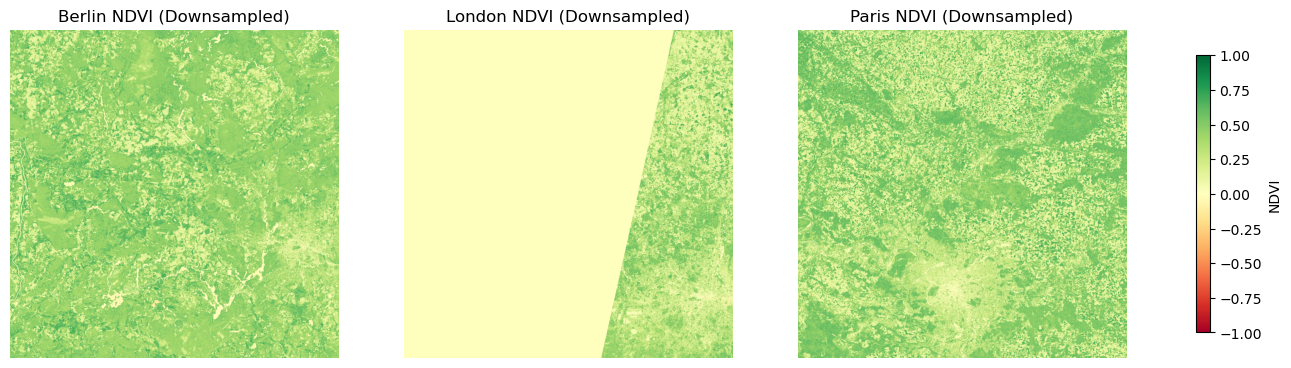

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))

for i, (city, paths) in enumerate(cities.items()):
    ndvi = compute_ndvi(paths["red"], paths["nir"])
    ndvi_small = ndvi[::10, ::10]
    
    ax = axes[i]
    im = ax.imshow(ndvi_small, cmap='RdYlGn', vmin=-1, vmax=1)
    ax.set_title(f"{city} NDVI (Downsampled)")
    ax.axis("off")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label="NDVI")
plt.show()



In [12]:
print("Mean NDVI for each city:")
for city, value in mean_ndvi.items():
    print(f"{city}: {value:.3f}")

Mean NDVI for each city:
Berlin: 0.396
London: 0.089
Paris: 0.369


In [14]:
for city, paths in cities.items():
    print(f"Processing {city} ...")

    ndvi = compute_ndvi(paths["red"], paths["nir"])
    ndvi_data[city] = ndvi


Processing Berlin ...
Processing London ...
Processing Paris ...


In [15]:
ndvi_data["Berlin"][150, 320]


np.float32(0.4159679)

In [ ]:
fig, axes = plt.subplots(1, len(cities), figsize=(6 * len(cities), 6))

for ax, city in zip(axes, cities.keys()):
    im = ax.imshow(ndvi_data[city], cmap="RdYlGn", vmin=-1, vmax=1)
    ax.set_title(f"{city} NDVI (per pixel)")
    ax.axis("off")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label="NDVI")
plt.show()



In [27]:
import os

output_folder = r"C:\Users\Lenovo\Documents\GeoinformationDataScience\EOPF\Project\NDVI\output"
os.makedirs(output_folder, exist_ok=True)  # creates folder if it doesn't exist


In [28]:
for city, paths in cities.items():
    ndvi = ndvi_data[city]

    with rasterio.open(paths["red"]) as src:
        profile = src.profile

    profile.update(
        dtype=rasterio.float32,
        count=1,
        compress='lzw',
        driver='GTiff'
    )

    out_name = os.path.join(output_folder, f"{city}_NDVI.tif")
    with rasterio.open(out_name, "w", **profile) as dst:
        dst.write(ndvi.astype(rasterio.float32), 1)

    print(f"Saved {out_name}")


Saved C:\Users\Lenovo\Documents\GeoinformationDataScience\EOPF\Project\NDVI\output\Berlin_NDVI.tif
Saved C:\Users\Lenovo\Documents\GeoinformationDataScience\EOPF\Project\NDVI\output\London_NDVI.tif
Saved C:\Users\Lenovo\Documents\GeoinformationDataScience\EOPF\Project\NDVI\output\Paris_NDVI.tif
